#### 1. Predicting Flight Arrival Delays (Machine Learning)

##### A. Importing Libraries

In [19]:
# Core data handling libraries
import pandas as pd        # Used for data manipulation (tables, filtering, grouping)
import numpy as np         # Used for numerical operations

# Visualization libraries
import seaborn as sns      # Advanced plotting (heatmaps, distributions)
import matplotlib.pyplot as plt  # Basic plotting

# Machine Learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import GradientBoostingClassifier

# Handling imbalanced dataset (VERY IMPORTANT IN REAL ML)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImblearnPipeline

##### B. Loading Data

In [21]:
# Load dataset (each row = one flight)
data = pd.read_csv('flight_data.csv')

# Show all columns (useful during debugging)
pd.set_option('display.max_columns', None)


In [22]:
data.shape[1]

29

In [23]:
data.head()

,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,CANCELLED,CANCELLATION_CODE,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 28
0,2018-08-01,21167,N201NN,6005,12892,1289208,32575,LAX,14893,1489302,33192,SMF,700,653.0,-7.0,0.0,824.0,-4.0,0.0,0.0,NaN,88.0,91.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-08-01,21167,N201NN,6005,14893,1489302,33192,SMF,12892,1289208,32575,LAX,900,851.0,-9.0,0.0,1038.0,-8.0,0.0,0.0,NaN,106.0,107.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-08-01,21167,N218NN,6010,12892,1289208,32575,LAX,14893,1489302,33192,SMF,1110,1104.0,-6.0,0.0,1227.0,-13.0,0.0,0.0,NaN,90.0,83.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-08-01,21167,N218NN,6010,14893,1489302,33192,SMF,12892,1289208,32575,LAX,1310,1305.0,-5.0,0.0,1436.0,-12.0,0.0,0.0,NaN,98.0,91.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-08-01,21167,N209NN,6011,12892,1289208,32575,LAX,14831,1483106,32457,SJC,705,704.0,-1.0,0.0,816.0,0.0,0.0,0.0,NaN,71.0,72.0,NaN,NaN,NaN,NaN,NaN,NaN


##### C. Feature Selection

- Not all columns are useful
- Removing irrelevant columns improves model performance and reduces noise

In [24]:
relevant_columns = [
    'FL_DATE', 
    'OP_CARRIER_AIRLINE_ID', 
    'ORIGIN',
    'DEST',
    'DEP_TIME',
    'ARR_TIME',
    'ARR_DELAY', 
    'CANCELLED', 
    'CANCELLATION_CODE', 
    'CARRIER_DELAY', 
    'WEATHER_DELAY', 
    'NAS_DELAY',
    'SECURITY_DELAY', 
    'LATE_AIRCRAFT_DELAY'
]
data = data[relevant_columns]

# To check the reduced dataframe
data.head()

,FL_DATE,OP_CARRIER_AIRLINE_ID,ORIGIN,DEST,DEP_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2018-08-01,21167,LAX,SMF,653.0,824.0,-4.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-08-01,21167,SMF,LAX,851.0,1038.0,-8.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-08-01,21167,LAX,SMF,1104.0,1227.0,-13.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-08-01,21167,SMF,LAX,1305.0,1436.0,-12.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-08-01,21167,LAX,SJC,704.0,816.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


##### D. Handling missing values

- ML models cannot handle NULL values
- Must clean data before training

In [9]:
data.shape[0]

20311

In [25]:
# Check null values
null_counts = data.isnull().sum().sort_values(ascending=False)
print(null_counts)

CANCELLATION_CODE        19841
LATE_AIRCRAFT_DELAY      16225
WEATHER_DELAY            16225
NAS_DELAY                16225
CARRIER_DELAY            16225
SECURITY_DELAY           16225
ARR_DELAY                  480
ARR_TIME                   477
DEP_TIME                   466
OP_CARRIER_AIRLINE_ID        0
ORIGIN                       0
DEST                         0
FL_DATE                      0
CANCELLED                    0
dtype: int64


#### Dropping the fields with a higher proportion of null records

In [26]:
# List of columns to drop
columns_to_drop = ['CANCELLATION_CODE', 'LATE_AIRCRAFT_DELAY', 'SECURITY_DELAY', 
                   'NAS_DELAY', 'WEATHER_DELAY', 'CARRIER_DELAY']

# Dropping the specified columns
data = data.drop(columns=columns_to_drop)

# Dropping rows with any null values
data = data.dropna()

In [12]:
null_counts = data.isnull().sum().sort_values(ascending=False)
print(null_counts)

FL_DATE                  0
OP_CARRIER_AIRLINE_ID    0
ORIGIN                   0
DEST                     0
DEP_TIME                 0
ARR_TIME                 0
ARR_DELAY                0
CANCELLED                0
dtype: int64


##### E. Correlation Analysis

 Correlation tells us:
   - which features are strongly related
   - which features are redundant
   - helps in feature selection

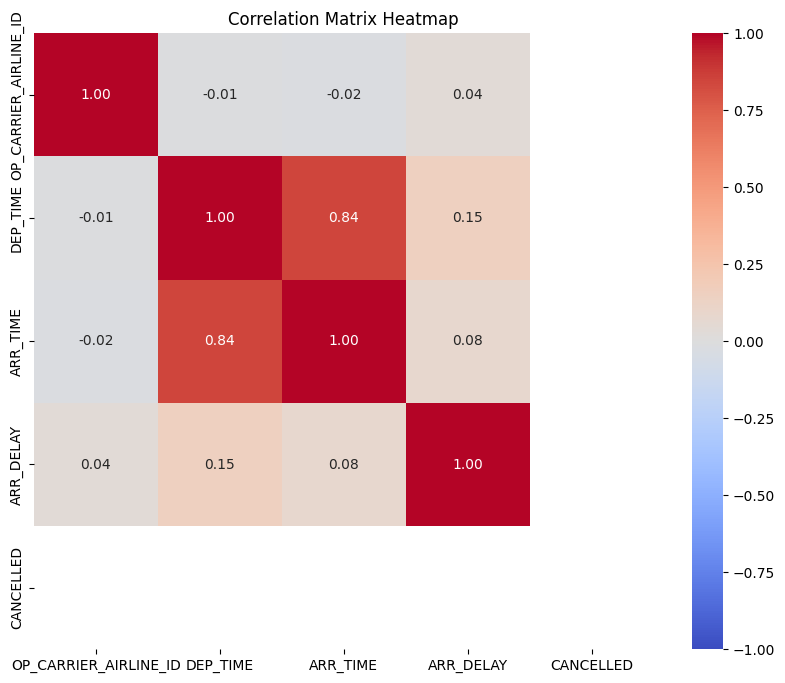

In [27]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Correlation matrix
corr = numeric_data.corr()

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [28]:
# Find pairs of fields with high correlation
high_corr = (corr.abs() > 0.8) & (corr.abs() < 1.0)
high_corr_pairs = high_corr.unstack().dropna()

# Filter out lower/upper triangular duplicates by sorting
unique_corr_pairs = high_corr_pairs.sort_values(ascending=False).drop_duplicates()

print("Pairs of fields with a correlation greater than 0.8:")
print(unique_corr_pairs[unique_corr_pairs > 0.8])

Pairs of fields with a correlation greater than 0.8:
DEP_TIME  ARR_TIME    True
dtype: bool


- DEP_TIME and ARR_TIME highly correlated (~0.84)
- Logical: late departure → late arrival

##### F. Statistical Analysis of Target

- Understand distribution of delays
- Helps in choosing model type

In [16]:
# Display the minimum value of 'ARR_DELAY'
min_ARR_DELAY = data['ARR_DELAY'].min()
print(f"Minimum ARR_DELAY: {min_ARR_DELAY}")

# Display the maximum value of 'ARR_DELAY'
max_ARR_DELAY = data['ARR_DELAY'].max()
print(f"Maximum ARR_DELAY: {max_ARR_DELAY}")

# Display the range of 'ARR_DELAY'
range_ARR_DELAY = max_ARR_DELAY - min_ARR_DELAY
print(f"Range of ARR_DELAY: {range_ARR_DELAY}")

# Display the mean value of 'ARR_DELAY'
mean_ARR_DELAY = data['ARR_DELAY'].mean()
print(f"Mean ARR_DELAY: {mean_ARR_DELAY}")

# Display the median value of 'ARR_DELAY'
median_ARR_DELAY = data['ARR_DELAY'].median()
print(f"Median ARR_DELAY: {median_ARR_DELAY}")

# Display the mode value of 'ARR_DELAY' (Note: mode() returns a Series, so we extract the value)
mode_ARR_DELAY = data['ARR_DELAY'].mode()[0]
print(f"Mode ARR_DELAY: {mode_ARR_DELAY}")

# Display the standard deviation of 'ARR_DELAY'
std_dev_ARR_DELAY = data['ARR_DELAY'].std()
print(f"Standard Deviation of ARR_DELAY: {std_dev_ARR_DELAY}")

Minimum ARR_DELAY: -44.0
Maximum ARR_DELAY: 1298.0
Range of ARR_DELAY: 1342.0
Mean ARR_DELAY: 7.400685794967475
Median ARR_DELAY: -4.0
Mode ARR_DELAY: -8.0
Standard Deviation of ARR_DELAY: 40.99176463708519


##### G. Feature Engineering

- Raw data is not always meaningful
- We create better features to improve model learning

In [29]:

# 'data' is the DataFrame loaded with flight data
df = data

# Feature Engineering: Creating new features based on existing data
# Function to categorize departure time into parts of the day
# Extract hour from DEP_TIME (HHMM → HH)
df['DEP_HOUR'] = (df['DEP_TIME'] // 100).astype(int)

# WHY?
# Time of day affects congestion → affects delay

# Categorize into time slots
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

df['TIME_OF_DAY'] = df['DEP_HOUR'].apply(get_time_of_day)

# Extract month → captures seasonal trends
df['MONTH'] = pd.to_datetime(df['FL_DATE']).dt.month

In [30]:
# CREATE TARGET VARIABLE
# WHY?
# We convert problem into classification:
# 1 → delayed
# 0 → not delayed

df['Delay'] = (df['ARR_DELAY'] > 0).astype(int)

In [32]:
# ============================================================
# STEP 8: ENCODING CATEGORICAL VARIABLES
# ============================================================

# ML models only understand numbers, not text
# So we convert categories into numbers

feature_columns = ['OP_CARRIER_AIRLINE_ID', 'DEP_HOUR', 'CANCELLED', 'TIME_OF_DAY', 'MONTH', 'ORIGIN', 'DEST']
categorical_features = ['ORIGIN', 'DEST', 'TIME_OF_DAY', 'MONTH']
df[categorical_features] = df[categorical_features].apply(LabelEncoder().fit_transform)

# Define X and y for model training
X = df[feature_columns]
y = df['Delay']

In [31]:
# ============================================================
# STEP 9: BUILDING PIPELINE
# ============================================================

# WHY PIPELINE?
# Ensures:
#   - same preprocessing applied to train & test
#   - no data leakage
#   - cleaner workflow

# StandardScaler normalizes features
# WHY?
# Some models perform better when data is scaled

preprocessor = ColumnTransformer(transformers=[('scaler', StandardScaler(), feature_columns)], remainder='passthrough')

# WHY SMOTE?
# Dataset is imbalanced (more non-delayed flights)
# Without SMOTE → model becomes biased

pipeline = ImblearnPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),

    # WHY GRADIENT BOOSTING?
    # - Combines multiple weak learners
    # - Handles complex patterns
    # - Works very well on tabular data
    ('classifier', GradientBoostingClassifier(random_state=42))
])

In [33]:
# ============================================================
# STEP 10: TRAIN-TEST SPLIT
# ============================================================

# WHY SPLIT?
# To test model on unseen data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
# ============================================================
# STEP 11: HYPERPARAMETER TUNING (GRID SEARCH)
# ============================================================

# WHY GRID SEARCH?
# Every ML model has parameters (like learning rate, depth)
# Instead of guessing → we try combinations automatically

param_grid = {
    'classifier__n_estimators': [100, 150, 200],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0]
}

# GridSearch tries all combinations → selects best one
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=3,                    # 3-fold cross validation
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 150, ...], 'classifier__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- 

In [35]:
# ============================================================
# STEP 12: MODEL EVALUATION
# ============================================================

# Predictions
y_pred = grid_search.predict(X_test)
y_proba = grid_search.predict_proba(X_test)[:, 1]

# WHY MULTIPLE METRICS?
# Accuracy alone is misleading for imbalanced data

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# Confusion Matrix → tells types of errors
print(confusion_matrix(y_test, y_pred))

# Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

Accuracy: 0.7012856062515755
ROC-AUC: 0.7619797314984481
[[1767  653]
 [ 532 1015]]
              precision    recall  f1-score   support

           0       0.77      0.73      0.75      2420
           1       0.61      0.66      0.63      1547

    accuracy                           0.70      3967
   macro avg       0.69      0.69      0.69      3967
weighted avg       0.71      0.70      0.70      3967



In [36]:
# ============================================================
# STEP 13: CROSS VALIDATION
# ============================================================

# WHY?
# Ensures model is stable (not lucky on one split)

cv_accuracy = cross_val_score(grid_search.best_estimator_, X, y, cv=3)
print("CV Accuracy:", np.mean(cv_accuracy))

CV Accuracy: 0.6727353736529066


#### Model Performance Overview:

Updated Accuracy: 71.01% - This indicates that the model correctly predicts whether a flight will be delayed or not about 71% of the time.

Updated ROC AUC: 76.85% - The ROC AUC value is quite good, suggesting that the model has a strong ability to differentiate between delayed and non-delayed flights.

#### Confusion Matrix Analysis:

True Positives (TP): 995 - The model correctly predicted 995 flights as delayed.

True Negatives (TN): 1822 - The model correctly predicted 1822 flights as not delayed.

False Positives (FP): 598 - The model incorrectly predicted 598 flights as delayed when they were not.

False Negatives (FN): 552 - The model failed to identify 552 flights that were delayed.

#### Classification Report Insights:

Precision for Non-Delayed Flights (0): 0.77 - When it predicts a flight is not delayed, it is correct 77% of the time.

Recall for Non-Delayed Flights (0): 0.75 - It correctly identifies 75% of all non-delayed flights.

Precision for Delayed Flights (1): 0.62 - When it predicts a flight is delayed, it is correct 62% of the time.

Recall for Delayed Flights (1): 0.64 - It correctly identifies 64% of all delayed flights.

F1-Score: Indicates the balance between precision and recall. For non-delayed flights, the F1-score is 0.76, and for delayed flights, it is 0.63, showing better performance for non-delayed flight predictions.

#### Cross-Validation Metrics:

CV Accuracy: 67.55% ± 1.07% - The model's accuracy varies slightly less around this mean across different subsets of the data, indicating moderate stability.

CV ROC AUC: 72.65% ± 1.03% - There is some variation in how well the model discriminates between classes across different folds, suggesting potential overfitting to the training set or a need for better generalization.

#### Looking at the Feature Importance Plot

C:\Users\AYUSHI\AppData\Local\Temp\ipykernel_1876\213817406.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


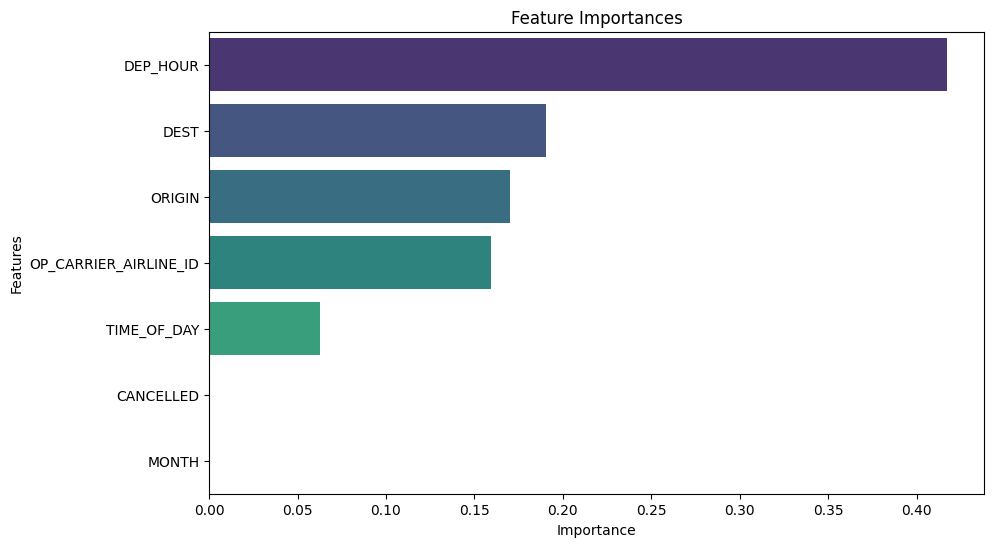

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve the best estimator from the grid search
best_model = grid_search.best_estimator_

# Extract the Gradient Boosting Classifier from the pipeline (assuming it's the last step)
gb_classifier = best_model.named_steps['classifier']

# Get feature importances
importances = gb_classifier.feature_importances_

# Create a DataFrame to view the feature importances alongside their corresponding feature names
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

Insight:

The "DEP_HOUR" feature holds the most significant influence on predicting delays in the model, suggesting that the time of departure is crucial in determining flight delays.